# Phishing Email Detection Using Natural Language Processing: A Comparative Study of Classical Machine Learning and Transformer Models

## Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

#Uncomment them and download them once to run properly
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

# Initialize
stop_words = set(stopwords.words('english'))

# Set plot style (White background, no grid)
sns.set_style("white")

## Initial Overview

In [2]:
# Load dataset
df = pd.read_csv('phishing_email_corpus.csv')

# Display basic information
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Info ---")
df.info()
print("\n--- Head ---")
print(df.head())

--- Dataset Shape ---
(44720, 3)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44720 entries, 0 to 44719
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   44720 non-null  object
 1   label   44720 non-null  int64 
 2   source  44720 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB

--- Head ---
                                               email  label   source
0  This text is part of the internal format of yo...      1  Nazario
1  Business with  \t\t\t\t\t\t\t\tcPanel & WHM \t...      1  Nazario
2  Your two incoming mails were placed on pending...      1  Nazario
3  Password will expire in 3 days. Click Here To ...      1  Nazario
4  To ensure delivery to your inbox, please add U...      1  Nazario


## Label Distribution

Percentage of Phishing (1): 55.67%
Percentage of Legitimate (0): 44.33%


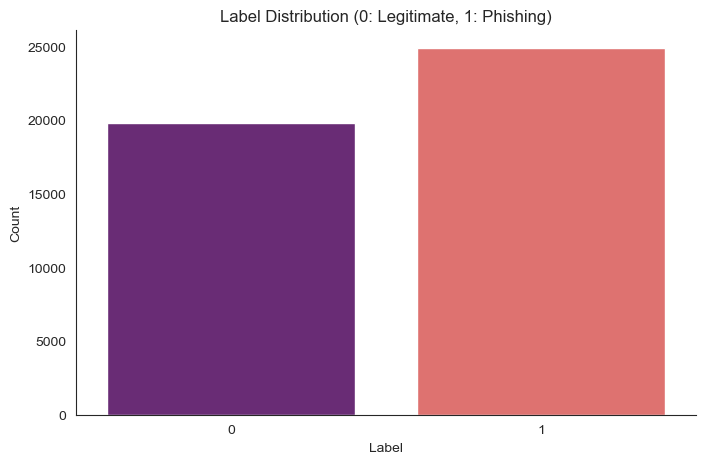

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, hue='label', palette='magma', legend=False)

plt.title('Label Distribution (0: Legitimate, 1: Phishing)')
plt.xlabel('Label')
plt.ylabel('Count')

# Calculate percentages
counts = df['label'].value_counts(normalize=True) * 100
print(f"Percentage of Phishing (1): {counts[1]:.2f}%")
print(f"Percentage of Legitimate (0): {counts[0]:.2f}%")

sns.despine() 
plt.show()

## Source Distribution

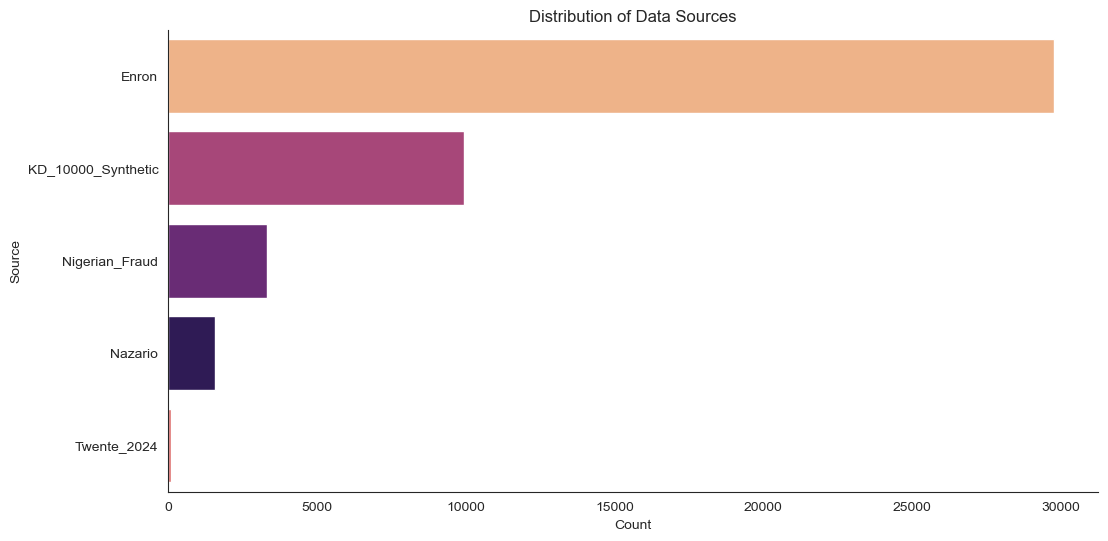

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(y='source', data=df, order=df['source'].value_counts().index, hue='source', palette='magma', legend=False)

plt.title('Distribution of Data Sources')
plt.xlabel('Count')
plt.ylabel('Source')

sns.despine()
plt.show()

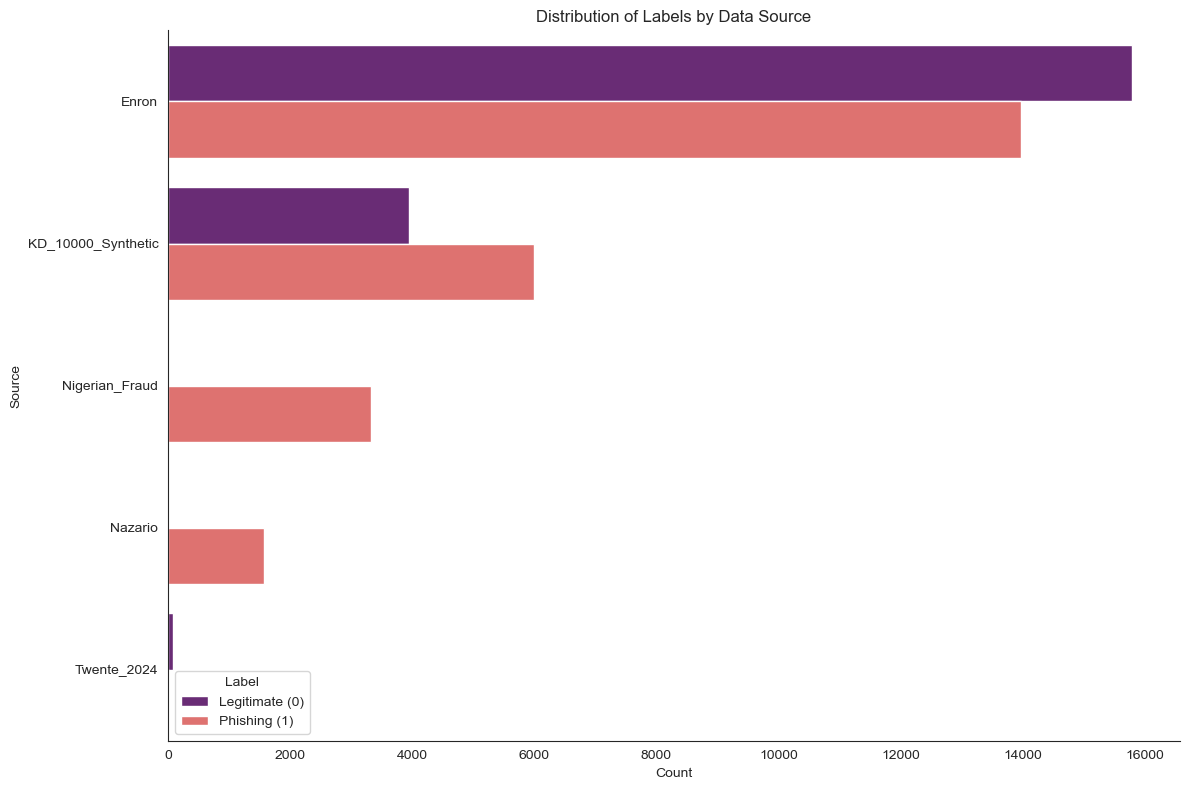

In [5]:
plt.figure(figsize=(12, 8))

sns.countplot(
    y='source', 
    data=df, 
    order=df['source'].value_counts().index, 
    hue='label', 
    palette='magma'
)

plt.title('Distribution of Labels by Data Source')
plt.xlabel('Count')
plt.ylabel('Source')

plt.legend(title='Label', labels=['Legitimate (0)', 'Phishing (1)'])

sns.despine()
plt.tight_layout()
plt.show()

## Semantic Feature Profiling

In [6]:
enron_signal_words = {'enron', 'ect', 'hou', 'vince', 'subject', 'cc', 'pm', 'corp'}

def clean_email_standard(email):
    if not isinstance(email, str): 
        return ""
    
    # Emails tokenization
    email_pattern = r'\b[a-z0-9._%+-]+[\s]*[@][\s]*[a-z0-9.-]+[\s]*[.][\s]*[a-z]{2,6}\b'
    email = re.sub(email_pattern, ' email_token ', email)

    # URLs tokenization
    url_pattern = r'(?:(?:https?|ftp)[\s]*[:][\s]*/*|www[\s]*[\.])[^\s<>"]+|(?:[a-z0-9-]+[\s]*[\.])+[\s]*(?:com|org|net|edu|gov|io|cc|ly|me|info|biz|tv)\b'
    email = re.sub(url_pattern, ' url_token ', email)

    # Numbers removal 
    email = re.sub(r'\d+', ' ', email)

    # Lowercase
    email = email.lower()

    # Stopword removal
    words = email.split()
    clean_words = [w for w in words if w not in stop_words]
    return " ".join(clean_words)

def clean_email_no_signal(email_text):
    words = email_text.split()
    return " ".join([w for w in words if w not in enron_signal_words])
    
df['clean_email'] = df['email'].apply(clean_email_standard)
df['clean_email_no_signal'] = df['clean_email'].apply(clean_email_no_signal)

In [7]:
def get_top_n_words(text_series, n=20):
    counter = Counter()
    for text in text_series:
        words = [w for w in text.split() if len(w) > 1]
        counter.update(words)
    return counter.most_common(n)

top_phishing = get_top_n_words(df[df['label'] == 1]['clean_email'])
top_legit = get_top_n_words(df[df['label'] == 0]['clean_email'])
top_legit_no_signal = get_top_n_words(df[df['label'] == 0]['clean_email_no_signal'])

print("\n--- Top 20 Words in Phishing Emails --- \n")
print(top_phishing)
print("\n--- Top 20 Words in Legitimate Emails --- \n")
print(top_legit)
print("\n--- Top 20 Words in Legitimate Emails after Removal of 'Enron' signal --- \n")
print(top_legit_no_signal)


--- Top 20 Words in Phishing Emails --- 

[('email_token', 54901), ('url_token', 24553), ('account', 15939), ('money', 13788), ('please', 12847), ('company', 12153), ('email', 11191), ('us', 9983), ('information', 9430), ('bank', 9241), ('business', 8940), ('security', 8801), ('may', 8567), ('one', 7570), ('time', 6724), ('contact', 6666), ('get', 6651), ('new', 6355), ('next', 6289), ('de', 6170)]

--- Top 20 Words in Legitimate Emails --- 

[('enron', 49291), ('ect', 34624), ('hou', 16657), ('please', 13721), ('would', 12082), ('subject', 11784), ('pm', 9586), ('email_token', 9516), ('company', 9421), ('said', 8923), ('cc', 8906), ('energy', 8789), ('new', 8746), ('thanks', 8579), ('gas', 8579), ('vince', 8544), ('know', 7899), ('url_token', 7845), ('power', 6950), ('corp', 6762)]

--- Top 20 Words in Legitimate Emails after Removal of 'Enron' signal --- 

[('please', 13721), ('would', 12082), ('email_token', 9516), ('company', 9421), ('said', 8923), ('energy', 8789), ('new', 8746),

## Special Character & URL Count

In [8]:
df['url_count'] = df['clean_email_no_signal'].str.count('url_token')
df['email_count'] = df['clean_email_no_signal'].str.count('email_token')
df['exclamation_count'] = df['email'].str.count('!')
df['question_count'] = df['email'].str.count(r'\?')

stats_cols = ['url_count', 'email_count', 'exclamation_count', 'question_count']
comparison_df = df.groupby('label')[stats_cols].mean()

print("--- Average Counts per Email Type --- \n")
print(comparison_df)

--- Average Counts per Email Type --- 

       url_count  email_count  exclamation_count  question_count
label                                                           
0       0.395732     0.480024           0.520178        1.021287
1       0.986223     2.205214           1.155848        1.462404


## Uppercase Count

In [9]:
def calculate_uppercase_ratio(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    
    # Count only alphabetic characters to avoid dilution by spaces/numbers
    alpha_chars = [char for char in text if char.isalpha()]
    if not alpha_chars:
        return 0.0
    
    upper_count = sum(1 for char in alpha_chars if char.isupper())
    return upper_count / len(alpha_chars)

# Apply to the raw text column
df['upper_ratio'] = df['email'].apply(calculate_uppercase_ratio)

# Check the average by label
avg_upper = df.groupby('label')['upper_ratio'].mean()
print("--- Average Uppercase Ratio --- \n")
print(avg_upper)

--- Average Uppercase Ratio --- 

label
0    0.011854
1    0.036281
Name: upper_ratio, dtype: float64


## Vocabulary Analysis

### Vocabulary Size

In [10]:
all_tokens = set()
df['clean_email_no_signal'].str.split().apply(all_tokens.update)

print(f"--- Dataset Vocabulary Analysis --- \n")
print(f"Total number of unique tokens: {len(all_tokens):,}")
print(f"\nSample tokens: {list(all_tokens)[:30]}")

--- Dataset Vocabulary Analysis --- 

Total number of unique tokens: 431,425

Sample tokens: ['tszbcyqqqshjfaeidxc+kutdxdcwkrvhicgfis', 'pdafgujl', 'einmal', 'entschuldigen', 'svjhphr', 'jiuy', 'tmz', 'coordinated', 'ovgic', 'rqbyylcudbyyenxj', 'cibb', 'accounts,and', 'wednesday', 'scaro', 'vrg/svcwkpmy', 'iduwjtsiihrh', 'jrmps', 'exceilent', 'lm+j', 'i++v', "ãfâ¢ã¢â?sâ¬ã¢â?zâ¢ãfæ'ã?â?tãfâ¢ã¢â?sâ¬ã,â", 'gpu', 'pfi', 'above).', 'skewness', 'ifu', 'huzltvg', 'supernovae', 'yrstrip', 'director/c.e.o,']


### Heap's Law Curve

In [11]:
word_counts = []
vocab_growth = []
seen_tokens = set()

for text in df['clean_email_no_signal']:
    tokens = text.split()
    word_counts.append(len(tokens))
    for t in tokens:
        seen_tokens.add(t)
    vocab_growth.append(len(seen_tokens))

cumulative_words = np.cumsum(word_counts) / 1e6

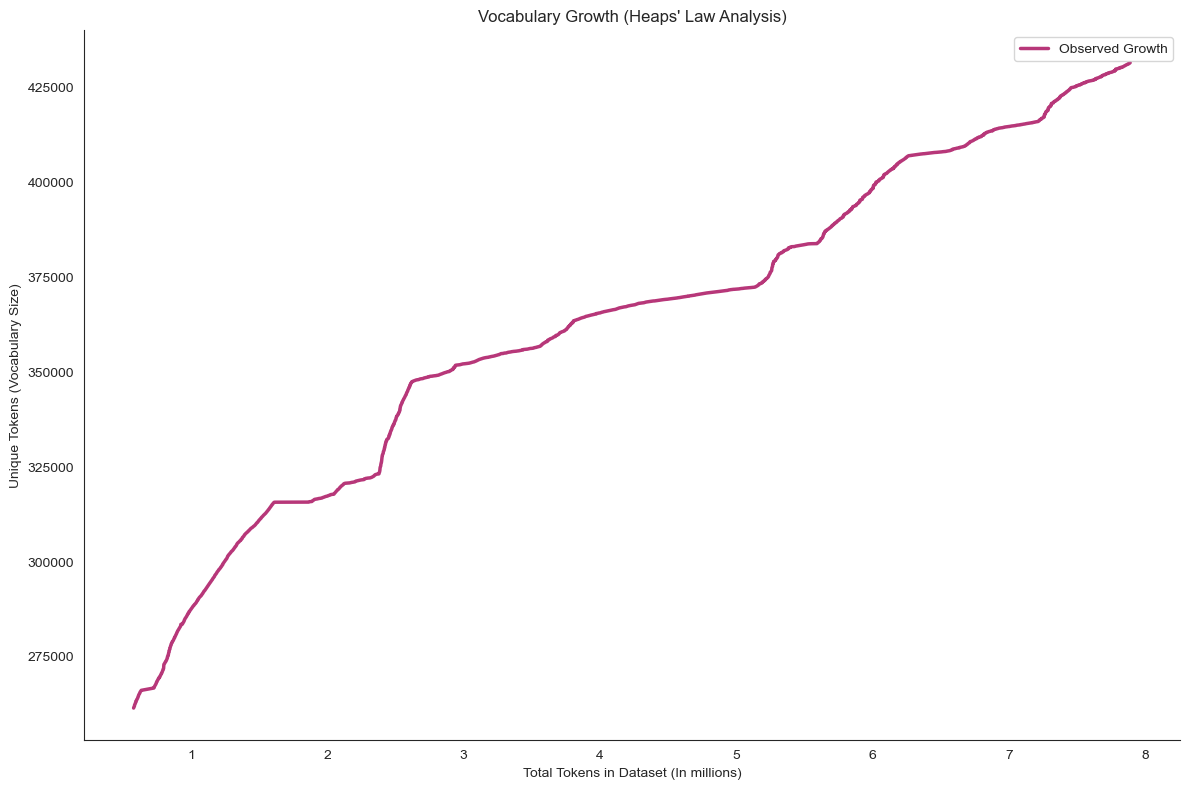

In [12]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    x=cumulative_words,
    y=vocab_growth,
    color=sns.color_palette("magma", 1)[0],
    linewidth=2.5,
    label='Observed Growth'
)
plt.title("Vocabulary Growth (Heaps' Law Analysis)")
plt.xlabel("Total Tokens in Dataset (In millions)")
plt.ylabel("Unique Tokens (Vocabulary Size)")
sns.despine()
plt.tight_layout()
plt.show()

### Hapax Legomena

In [13]:
word_freq = Counter()
for text in df['clean_email_no_signal']:
    word_freq.update(text.split())

hapax_legomena = [word for word, count in word_freq.items() if count == 1]

print(f"Number of Hapax Legomena: {len(hapax_legomena):,}\n")
print(f"Percentage of vocabulary: {(len(hapax_legomena)/len(all_tokens))*100:.2f}%\n")
print(f"Sample Hapax Tokens: {hapax_legomena[:30]}")

Number of Hapax Legomena: 317,661

Percentage of vocabulary: 73.63%

Sample Hapax Tokens: ['a=ypohruhcn', 'rwpnje:', 'a=cd', 'kfosnzpgqetwe:', 'a=cbjk', 'kloaaaa:', 'a=zf_', 'myqhkkry', 'vrt:', 'a=xsjchrr', 'gnqg-uos:', 'a=dgj', 'izp_ao', 'wwstc:', '.sense', 'bb,d', 'a=vpxqyhzzjwng', 'zb:', 'a=g', 'aj:', 'btrai', 'wa:', 'okemtmdrea:', 'a=zgokatccaaaa:', 'a=rrfzkelb', 'ikmeg-', 'a=lmrmxnsektufrwk', 'a=lbb', 'vzbhe', 'adeq:']


## Stable Vocabulary

In [16]:
word_freq = Counter()
for text in df['clean_email_no_signal']:
    word_freq.update(text.split())

min_counts = [3, 5, 7, 10]

for m in min_counts:
    stable_vocab = {word for word, count in word_freq.items() if count >= m}
    col_name = f'stable_vocab_{m}'
    
    df[col_name] = df['clean_email_no_signal'].apply(
        lambda x: " ".join([w for w in x.split() if w in stable_vocab])
    )
    
    print(f"\n--- Threshold: Min Count {m} ---")
    print(f"Stable Vocabulary Size: {len(stable_vocab):,}")
    print(f"Reduction of: {((total_vocab_size - len(stable_vocab)) / total_vocab_size) * 100:.2f}%")


--- Threshold: Min Count 3 ---
Stable Vocabulary Size: 81,177
Reduction of: 81.18%

--- Threshold: Min Count 5 ---
Stable Vocabulary Size: 55,561
Reduction of: 87.12%

--- Threshold: Min Count 7 ---
Stable Vocabulary Size: 42,487
Reduction of: 90.15%

--- Threshold: Min Count 10 ---
Stable Vocabulary Size: 31,390
Reduction of: 92.72%


In [17]:
for m in [3, 5, 7, 10]:
    col_name = f'stable_vocab_{m}'
    top_phishing = get_top_n_words(df[df['label'] == 1][col_name])
    top_legit = get_top_n_words(df[df['label'] == 0][col_name])

    print(f"\n{'='*20} Min Count {m} {'='*20}")
    print(f"Top 20 Phishing:\n{top_phishing}")
    print(f"\nTop 20 Legitimate:\n{top_legit}")


==================== Min Count 3 ====================
Top 20 Phishing:
[('email_token', 54901), ('url_token', 24553), ('account', 15939), ('money', 13788), ('please', 12847), ('company', 12153), ('email', 11191), ('us', 9983), ('information', 9430), ('bank', 9241), ('business', 8940), ('security', 8801), ('may', 8567), ('one', 7570), ('time', 6724), ('contact', 6666), ('get', 6651), ('new', 6355), ('next', 6289), ('de', 6170)]

Top 20 Legitimate:
[('please', 13721), ('would', 12082), ('email_token', 9516), ('company', 9421), ('said', 8923), ('energy', 8789), ('new', 8746), ('thanks', 8579), ('gas', 8579), ('know', 7899), ('url_token', 7845), ('power', 6950), ('deal', 6430), ('may', 6411), ('time', 6397), ('let', 6152), ('message', 5834), ('also', 5709), ('business', 5588), ('trading', 5427)]

==================== Min Count 5 ====================
Top 20 Phishing:
[('email_token', 54901), ('url_token', 24553), ('account', 15939), ('money', 13788), ('please', 12847), ('company', 12153), 

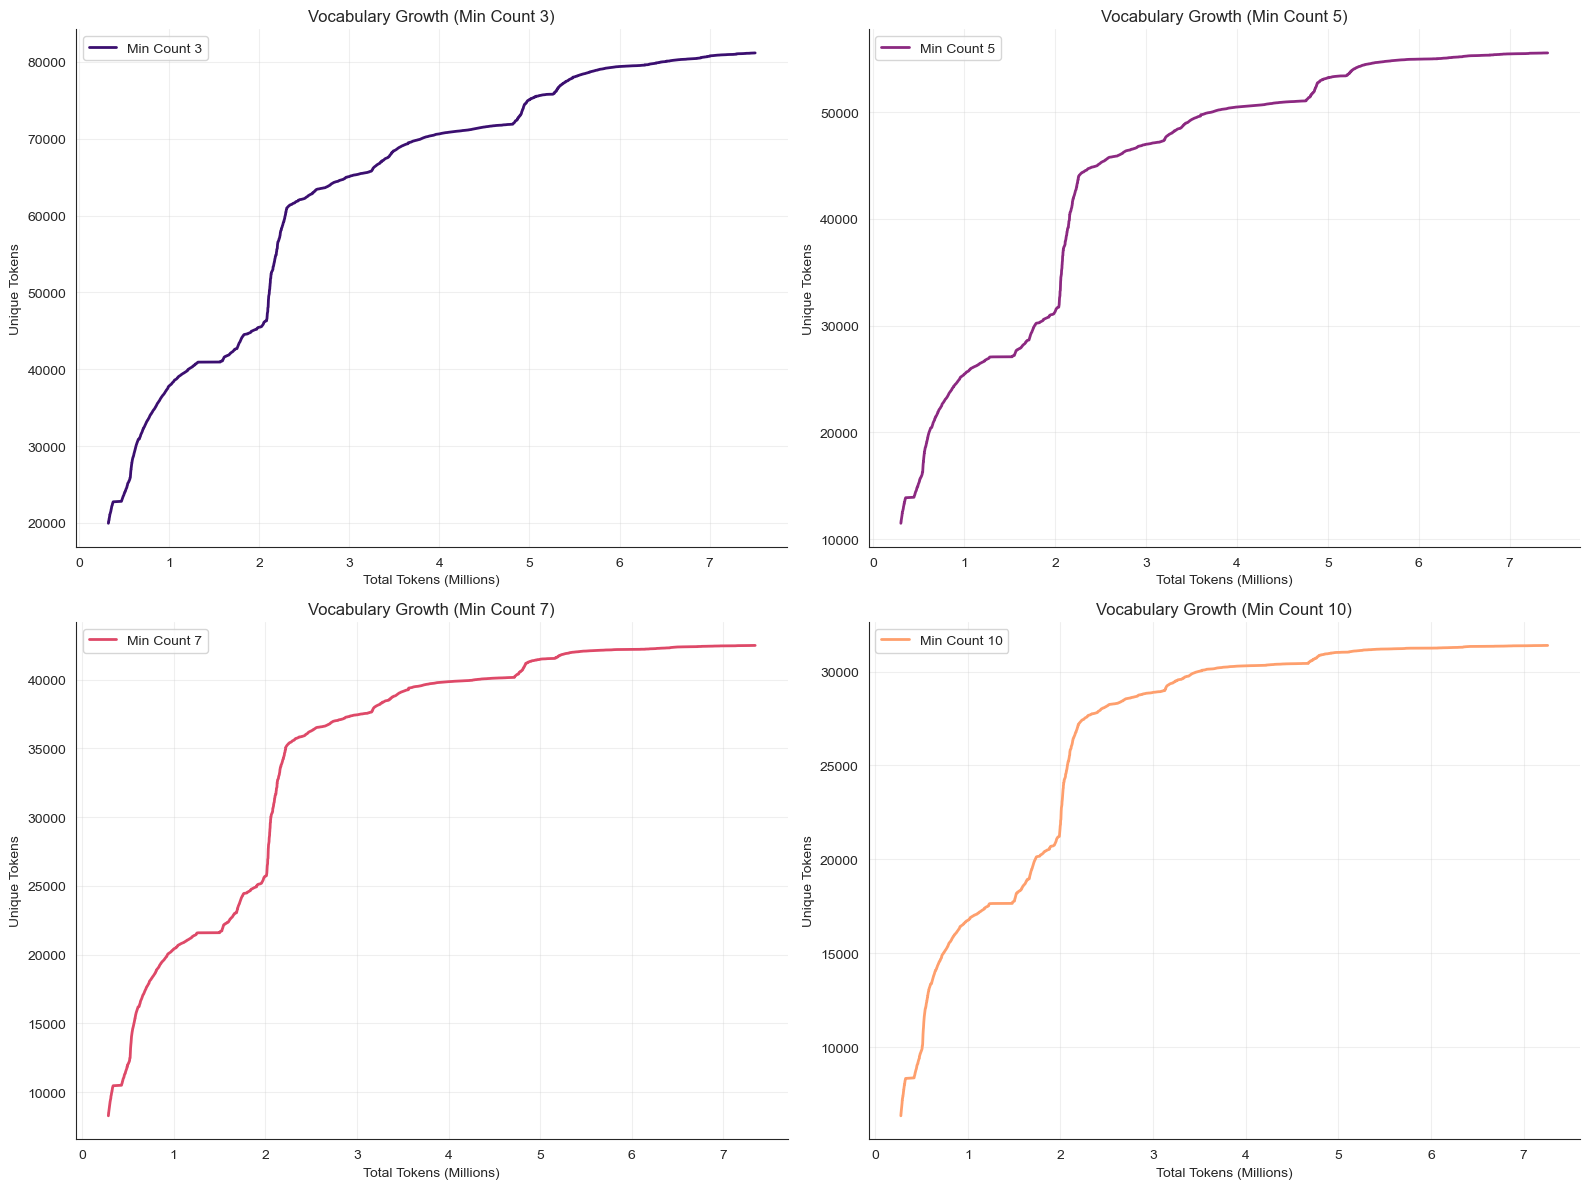

In [18]:
min_counts = [3, 5, 7, 10]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
colors = sns.color_palette("magma", len(min_counts))

for i, m in enumerate(min_counts):
    col_name = f'stable_vocab_{m}'
    word_counts = []
    vocab_growth = []
    seen_tokens = set()

    for text in df[col_name]:
        tokens = text.split()
        word_counts.append(len(tokens))
        for t in tokens:
            seen_tokens.add(t)
        vocab_growth.append(len(seen_tokens))

    cumulative_words = np.cumsum(word_counts) / 1e6

    sns.lineplot(
        x=cumulative_words,
        y=vocab_growth,
        ax=axes[i],
        color=colors[i],
        linewidth=2,
        label=f'Min Count {m}'
    )
    
    axes[i].set_title(f"Vocabulary Growth (Min Count {m})")
    axes[i].set_xlabel("Total Tokens (Millions)")
    axes[i].set_ylabel("Unique Tokens")
    axes[i].grid(True, alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

## Mini Report

**Label Distribution**: The dataset exhibits a relatively balanced distribution between classes, with a slight majority of phishing instances.

**Source Distribution**: The Enron dataset serves as the primary contributor, significantly outsized compared to the other sources, which as seen later, introduced a heavy organizational bias in the raw lexical data.

**Semantic Feature Profiling**: The lexical analysis process focuses on normalizing the dataset to extract meaningful thematic patterns while neutralizing structural and source-specific noise. The initial preprocessing pipeline converts all text to lowercase and removes numerical digits to focus on linguistic content. A key decision in this workflow was the use of regular expressions to perform "structural tokenization," where diverse URL and email formats are replaced with generic placeholders: url_token and email_token. By treating the presence of a link or contact information as a structural feature rather than unique strings, the analysis highlights the frequency of these elements as behavioral indicators.This is further refined during the tokenization phase, where the logic requires tokens to have a length greater than one to be considered a "word," effectively filtering out stray characters and noise that do not contribute to the semantic meaning of the text.

Beyond standard English stopword removal, a custom set of "Enron signal words" (such as enron, ect, hou, and vince) was identified and stripped from the legitimate class. This step was essential because these terms represent a source-specific bias, that would otherwise artificially distinguish legitimate emails based on company specific terminology rather than professional intent. The comparative results reveal a stark contrast in intent: phishing emails are heavily defined by financial and administrative triggers, with words like account, money, company, and bank dominating the top frequencies. The massive presence of email_token (over 55,000 occurrences) in phishing attempts underscores a systematic reliance on directing targets toward fraudulent contact points. In contrast, once the Enron-specific signals are removed, the legitimate emails reveal a procedural and professional core vocabulary, characterized by collaborative and transactional terms such as would, thanks, deal, gas, and energy.

**Special Character & URL Count**: Phishing emails demonstrate a clear structural divergence in their use of metadata and punctuation. On average (average occurrences per email), phishing samples contain 2.5 times more URLs and 4.5 times more email addresses than legitimate counterparts. Furthermore, the frequency of exclamation marks is more than double in fraudulent samples (1.16 vs 0.52), suggesting a higher reliance on syntactical urgency to elicit immediate user action. Question marks also appear more frequently in phishing attempts, likely reflecting the use of "call-to-action" queries or social engineering tactics designed to prompt a response. The dataset, after the Enron signal was removed, showed results consistent with the original findings, thus we kept the result from that.

*We use average counts for discrete tokens like URLs to measure volume, while using a ratio for uppercase characters to measure stylistic 'intensity' independent of the email's total length. The though is that a 10-word email and a 100-word email both having 1 link is the same "threat volume," but 10 capital letters in a short email is "shouting" (high density), while 10 capital letters in a long email is just standard grammar.*

**Uppercase Count**: The average uppercase ratio (average fraction of letters that are uppercase per email) in phishing emails (3.63%) is more than triple that of legitimate emails (1.19%). This disparity highlights a reliance on capitalized "call-to-action" phrases and emphasized urgency as a key architectural feature of fraudulent communication.

**Vocabulary Analysis**: The lexical sweep of the dataset, which was done by using a set() object to store tokens, automatically handling uniqueness, revealed an anomalously large vocabulary of 433,761 unique tokens from a corpus of only 44,720 emails. In typical English linguistic corpora, a dataset of this size would usually yield a vocabulary ($V$) between 50,000 and 100,000 unique words. This massive inflation suggests that the dataset is heavily "noisy," likely containing randomized strings, obfuscated URLs, and encoded content characteristic of modern spam and phishing techniques. To analyze the rate of vocabulary growth, we apply Heaps' Law, an empirical law in linguistics that describes the relationship between the number of unique words ($V$) and the total number of tokens ($N$) in a document: $V(N) = KN^{\beta}$, where:
* **$V$**: Vocabulary size (unique tokens).
* **$N$**: Cumulative number of tokens processed.
* **$K, \beta$**: Free parameters (with $0 < \beta < 1$).

The "Vocabulary Growth" graph for the raw data displays a nearly linear trajectory, rather than the expected logarithmic curve. In a standard language environment, the curve should flatten as the model "saturates" (meaning the probability of encountering a brand-new word decreases). The failure of our curve to flatten indicates that the dataset contains an "infinite" variety of unique strings, a high entropy noise that does not follow the rules of natural language. This theory is confirmed by the count of Hapax Legomena—tokens that occur exactly once in the entire corpus. Mathematically, while Zipf’s Law suggests that a significant portion of any vocabulary will be Hapaxes, a figure of 73.52% is extreme. Sample tokens like a=ypohruhcn and kfosnzpgqetwe: indicate that the majority of our vocabulary is composed of "garbage tokens." For a machine learning model, these represent "dead features" that increase dimensionality without providing any generalizable predictive power.

**Stable Vocabulary**: Building upon the initial discovery that over 73% of the vocabulary consisted of one-off "garbage tokens," the implementation of a multi-tiered Stable Vocabulary filter using minimum frequency thresholds of 3, 5, 7, and 10 was designed as a sensitivity analysis to determine the optimal balance between noise suppression and feature retention. This progressive pruning serves to test the robustness of the semantic signal. By observing how the vocabulary behaves as we tighten the requirements for "stability," we can identify the point at which we stop stripping away architectural noise and start losing meaningful linguistic patterns. The numerical results demonstrate a steep trajectory of dimensionality reduction: a threshold of 3 already eliminates 81.18% of the unique tokens, while a threshold of 10 minimizes the feature space by a staggering 92.72%, leaving a lean core of just 31,390 words from the original 433,761.

Through all that, as expected, the top 20 word frequencies for both phishing and legitimate classes remained virtually static across all four thresholds. This consistency confirms that the "intent" of the emails—the financial urgency of phishing (money, account, bank) and the procedural nature of legitimate Enron-era correspondence (would, thanks, energy)—is concentrated in a highly stable, high-frequency core rather than in the long tail of rare words. The fact that email_token and url_token maintain their dominance even at a minimum count of 10 reinforces the earlier finding that the structural "DNA" of phishing is its most persistent and repeatable feature.

The comparative Heaps' Law subplots provide the final visual validation for this strategy. As the minimum count threshold increases from 3 to 10, we observe the vocabulary growth curves transitioning from the near-linear "infinite noise" profile of the raw data toward a more traditional logarithmic curvature. The "Min Count 10" plot, in particular, exhibits a much flatter saturation point, indicating that we have successfully forced the dataset to behave like a natural language corpus. By stripping away nearly 93% of the unique strings, we have distilled the dataset into a manageable, high-density signal. For a machine learning model, this means the elimination of tens of thousands of "dead features" that would possibly cause overfitting, allowing the classifier to focus on the predictable, recurring markers of intent that survive even the most rigorous stability filters.

**Conclusion**: The initial analysis showed that the main issue with our dataset was the dominant “Enron” signal, which created a brand-specific shortcut instead of a generalizable pattern. Removing these Enron-specific terms shifted the focus to genuine professional language. However, while the removal of Enron-specific signals neutralized organizational bias, the Vocabulary Analysis suggests that phishing intent is codified not just in what is said (semantics), but in the statistical "chaos" of the vocabulary (noise density) and the intensity of the syntax (orthographic and punctuation markers). A successful detection strategy cannot rely on keywords alone. It must account for the structural "shouting" (punctuation and case) and the lexical "static" (unique noise tokens), that distinguish the mechanical nature of phishing from the stable, repetitive patterns of professional human correspondence.